In [2]:
# ── Cell 1: Setup ──────────────────────────────────────────────────────────────
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
})

In [3]:
# ── Cell 2: Load Processed Data ───────────────────────────────────────────────
abt    = pd.read_csv('C:/Users/Dell/Desktop/ecommerce-churn_prediction/data/processed/abt.csv', parse_dates=[
    'order_purchase_timestamp', 'order_approved_at',
    'order_delivered_customer_date', 'order_estimated_delivery_date',
    'order_delivered_carrier_date'
])
labels = pd.read_csv('C:/Users/Dell/Desktop/ecommerce-churn_prediction/data/processed/customer_labels.csv', parse_dates=[
    'order_purchase_timestamp', 'order_approved_at',
    'order_delivered_customer_date', 'order_estimated_delivery_date',
])

print(f"ABT    : {abt.shape}")
print(f"Labels : {labels.shape}")

ABT    : (96470, 16)
Labels : (93350, 18)


In [5]:
# ── Cell 3: Build Feature Matrix ──────────────────────────────────────────────
from importlib import reload
import src.features as feat
reload(feat)
from src.features import build_feature_matrix

feature_matrix = build_feature_matrix(abt, labels)

print(f"\nFeature matrix shape: {feature_matrix.shape}")
print(f"\nColumns:\n{list(feature_matrix.columns)}")
print(f"\nChurn distribution:\n{feature_matrix['will_return'].value_counts()}")

Nulls remain in feature matrix:
  approval_delay_hours: 13 (0.0%)
  speed_vs_promise_ratio: 13 (0.0%)



Feature matrix shape: (93350, 22)

Columns:
['customer_unique_id', 'customer_state', 'delivery_delay_days', 'approval_delay_hours', 'will_return', 'was_late', 'delivery_speed_days', 'estimated_speed_days', 'speed_vs_promise_ratio', 'has_review', 'review_score_filled', 'low_review', 'high_review', 'purchase_hour', 'purchase_dayofweek', 'purchase_month', 'is_weekend', 'is_business_hours', 'state_churn_rate', 'is_sao_paulo', 'is_remote_state', 'slow_approval']

Churn distribution:
will_return
0    90549
1     2801
Name: count, dtype: int64


In [6]:
# ── Cell 4: Feature Null & Type Audit ────────────────────────────────────────
print("── DTYPES & NULL CHECK ──")
summary = pd.DataFrame({
    'dtype'   : feature_matrix.dtypes,
    'nulls'   : feature_matrix.isnull().sum(),
    'pct_null': (feature_matrix.isnull().sum() / len(feature_matrix) * 100).round(2),
    'unique'  : feature_matrix.nunique(),
})
print(summary.to_string())

── DTYPES & NULL CHECK ──
                          dtype  nulls  pct_null  unique
customer_unique_id          str      0       0.0   93350
customer_state              str      0       0.0      27
delivery_delay_days       int64      0       0.0      55
approval_delay_hours    float64      0       0.0    4709
will_return               int64      0       0.0       2
was_late                  int64      0       0.0       2
delivery_speed_days       int64      0       0.0      46
estimated_speed_days      int64      0       0.0      45
speed_vs_promise_ratio  float64      0       0.0    1676
has_review                int64      0       0.0       2
review_score_filled     float64      0       0.0       5
low_review                int64      0       0.0       2
high_review               int64      0       0.0       2
purchase_hour             int32      0       0.0      24
purchase_dayofweek        int32      0       0.0       7
purchase_month            int32      0       0.0      12
is_we

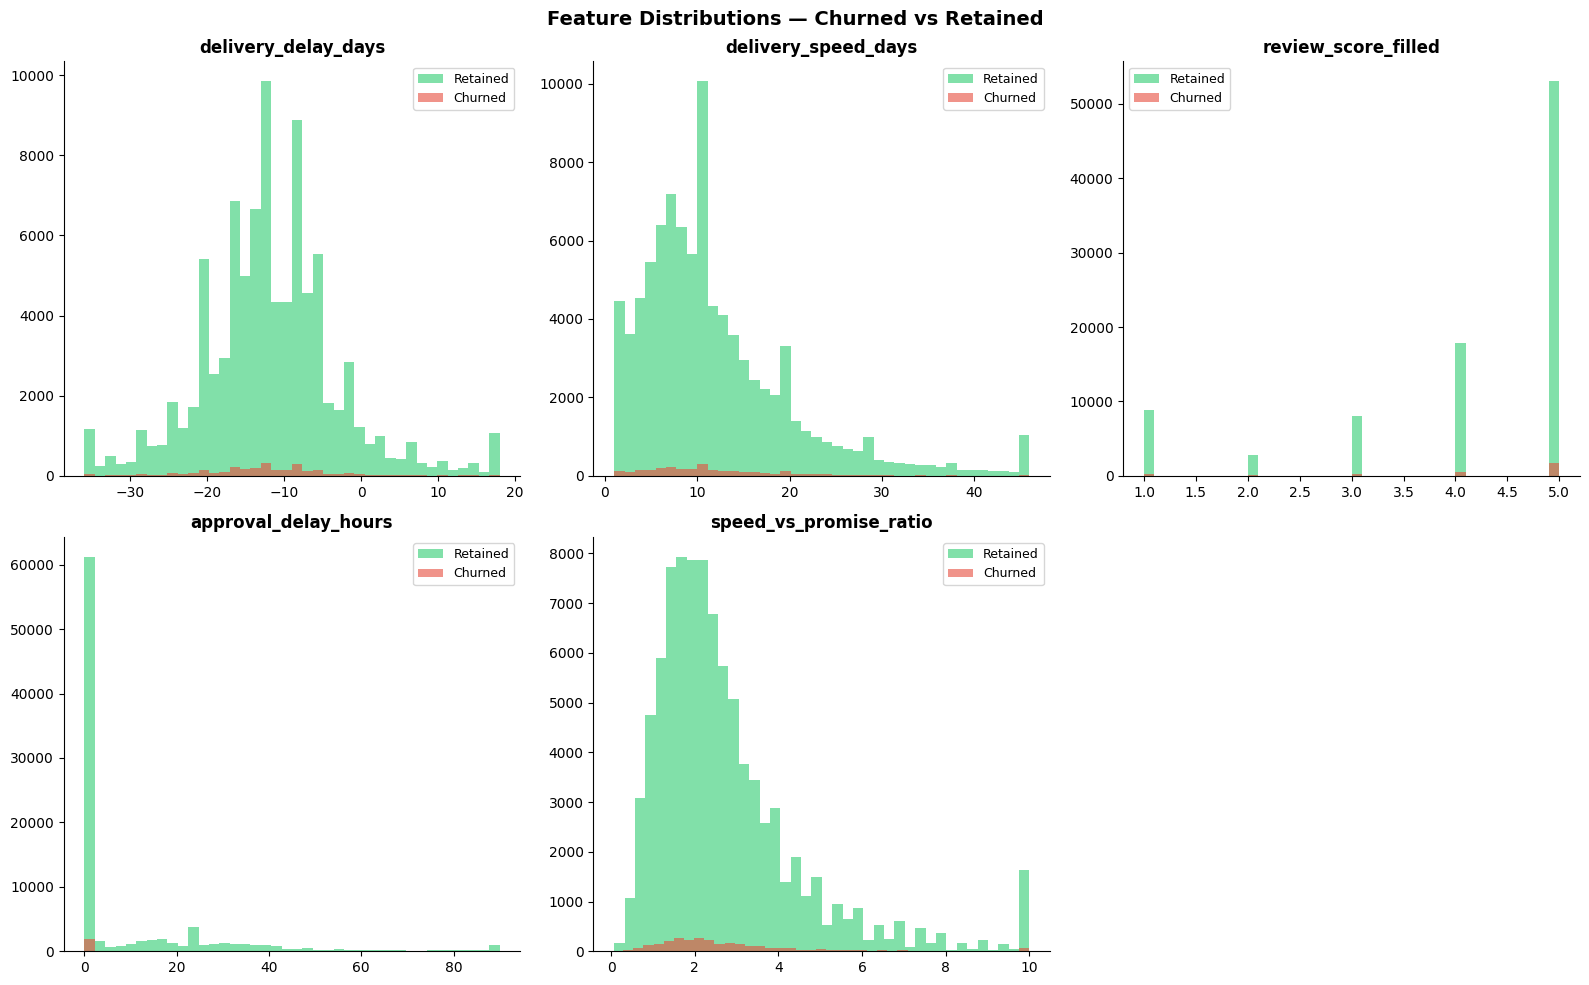

In [8]:
# ── Cell 5: Feature Distributions by Churn ───────────────────────────────────
num_features = [
    'delivery_delay_days', 'delivery_speed_days',
    'review_score_filled', 'approval_delay_hours',
    'speed_vs_promise_ratio'
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(num_features):
    ax = axes[i]
    for label, color, name in [(0, '#2ecc71', 'Retained'), (1, '#e74c3c', 'Churned')]:
        data = feature_matrix[feature_matrix['will_return'] == label][col].dropna()
        ax.hist(data, bins=40, alpha=0.6, color=color, label=name)
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('')
    ax.legend(fontsize=9)

axes[-1].axis('off')
plt.suptitle('Feature Distributions — Churned vs Retained', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/feature_distributions.png', bbox_inches='tight', dpi=150)
plt.show()

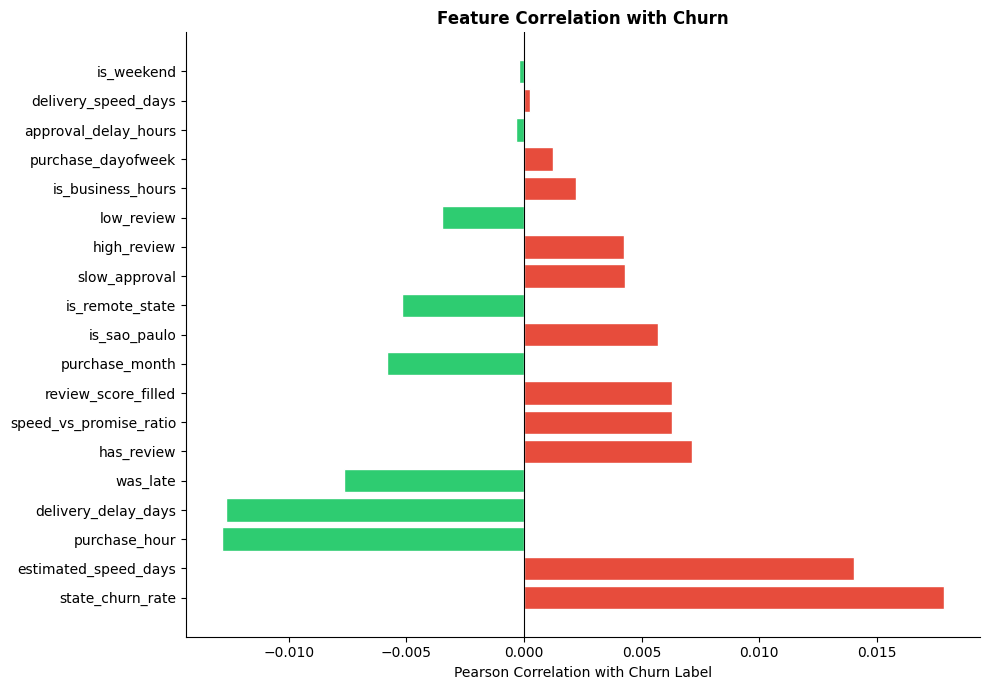


Top 5 features by correlation magnitude:
state_churn_rate        0.017855
estimated_speed_days    0.014039
purchase_hour           0.012837
delivery_delay_days     0.012692
was_late                0.007649


In [11]:
# ── Cell 6: Correlation With Churn ───────────────────────────────────────────
num_cols = feature_matrix.select_dtypes(include=np.number).columns.tolist()
num_cols = [c for c in num_cols if c not in ['will_return', 'customer_zip_code_prefix']]

correlations = (
    feature_matrix[num_cols + ['will_return']]
    .corr()['will_return']
    .drop('will_return')
    .sort_values(key=abs, ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in correlations.values]
ax.barh(correlations.index, correlations.values, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson Correlation with Churn Label')
ax.set_title('Feature Correlation with Churn', fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/feature_correlations.png', bbox_inches='tight', dpi=150)
plt.show()

print("\nTop 5 features by correlation magnitude:")
print(correlations.abs().sort_values(ascending=False).head(5).to_string())

In [12]:
# ── Cell 7: Save Feature Matrix ──────────────────────────────────────────────
feature_matrix.to_csv('../data/processed/feature_matrix.csv', index=False)
print(f"Saved → data/processed/feature_matrix.csv")
print(f"Shape : {feature_matrix.shape}")
print(f"\nFinal features going into model:")
model_cols = [c for c in feature_matrix.columns
              if c not in ['customer_unique_id', 'customer_state', 'will_return']]
for c in model_cols:
    print(f"  {c}")

Saved → data/processed/feature_matrix.csv
Shape : (93350, 22)

Final features going into model:
  delivery_delay_days
  approval_delay_hours
  was_late
  delivery_speed_days
  estimated_speed_days
  speed_vs_promise_ratio
  has_review
  review_score_filled
  low_review
  high_review
  purchase_hour
  purchase_dayofweek
  purchase_month
  is_weekend
  is_business_hours
  state_churn_rate
  is_sao_paulo
  is_remote_state
  slow_approval
